<a href="https://colab.research.google.com/github/Rifath-Mahmud/CVPR/blob/main/Neural%20Network%20Training%20Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)


cuda


In [2]:
data_folder = '~/data/MNIST'

# Load train data
mnist_train = datasets.MNIST(root=data_folder, train=True, download=True)
tr_images = mnist_train.data
tr_targets = mnist_train.targets

# Load test data
mnist_test = datasets.MNIST(root=data_folder, train=False, download=True)
te_images = mnist_test.data
te_targets = mnist_test.targets

print("Train images:", tr_images.shape, "\tTrain labels:", tr_targets.shape)
print("Test images: ", te_images.shape,  "\tTest labels: ",  te_targets.shape)


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 499kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.9MB/s]

Train images: torch.Size([60000, 28, 28]) 	Train labels: torch.Size([60000])
Test images:  torch.Size([10000, 28, 28]) 	Test labels:  torch.Size([10000])


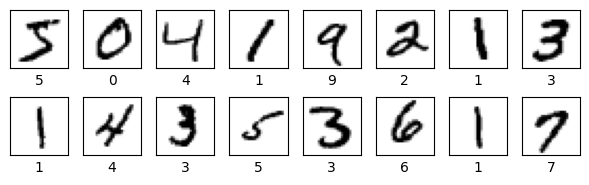

In [3]:
ROWS, COLS = 2 , 8
fig, axes = plt.subplots(ROWS, COLS, figsize=(6, 2))
for i, ax in enumerate(axes.flat):
    ax.imshow(tr_images[i], cmap="gray_r")
    ax.set_xlabel(tr_targets[i].item())
    ax.set(xticks=[], yticks=[])
plt.tight_layout()
plt.show()

In [4]:
class MNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255.0
        x = x.view(-1, 28 * 28)
        self.x, self.y = x, y

    def __getitem__(self, ix):
        return self.x[ix], self.y[ix]

    def __len__(self):
        return len(self.x)


In [5]:
## HyperParameters ##
training_epoch = 20
batch = 32
learning_rate = 1e-3

In [6]:
train = MNISTDataset(tr_images, tr_targets)
trn_dl = DataLoader(train, batch_size=batch, shuffle=True)

test = MNISTDataset(te_images, te_targets)
te_dl = DataLoader(test, batch_size=batch, shuffle=False)

In [7]:
from torch.optim import SGD
from torch.optim import Adam

def get_model():
    model = nn.Sequential(
                nn.Dropout(0.4),
                nn.Linear(28 * 28, 1000),
                nn.ReLU(),
                nn.Linear(1000, 512),
                nn.ReLU(),
                nn.Dropout(0.4),
                nn.Linear(512, 128),
                nn.ReLU(),
                nn.Linear(128, 10)
            ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=learning_rate)
    return model, loss_fn, optimizer


In [8]:
## Model ###
model, loss_fn, optimizer = get_model()
from torchsummary import summary
summary(model,(1,784))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Dropout-1               [-1, 1, 784]               0
            Linear-2              [-1, 1, 1000]         785,000
              ReLU-3              [-1, 1, 1000]               0
            Linear-4               [-1, 1, 512]         512,512
              ReLU-5               [-1, 1, 512]               0
           Dropout-6               [-1, 1, 512]               0
            Linear-7               [-1, 1, 128]          65,664
              ReLU-8               [-1, 1, 128]               0
            Linear-9                [-1, 1, 10]           1,290
Total params: 1,364,466
Trainable params: 1,364,466
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 5.21
Estimated Total Size (MB): 5.24
---------------------------------------

In [63]:
def train_batch(x, y, model, loss_fn, optimizer):
    model.train()
    optimizer.zero_grad()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    optimizer.step()
    return batch_loss.item()

@torch.no_grad()
def batch_accuracy(x, y, model):
    model.eval()
    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()


def train_one_epoch(data_loader, model, loss_fn, optimizer):
    epoch_losses, epoch_accuracies = [], []
    for batch in data_loader:
        x, y = batch
        x, y = x.to(device), y.to(device)   # move to device here
        batch_loss = train_batch(x, y, model, loss_fn, optimizer)
        epoch_losses.append(batch_loss)
        epoch_accuracies.extend(batch_accuracy(x, y, model))
    return np.array(epoch_losses).mean(), np.array(epoch_accuracies).mean()


@torch.no_grad()
def validation(data_loader, model, loss_fn):
    val_losses, val_accuracies = [], []
    model.eval()
    for x, y in data_loader:
        x, y = x.to(device), y.to(device)   # move to device here
        prediction = model(x)
        val_losses.append(loss_fn(prediction, y).item())
        val_accuracies.extend(batch_accuracy(x, y, model))
    return np.array(val_losses).mean(), np.array(val_accuracies).mean()

@torch.no_grad()
def predictOne(model,img,classes = None):
  img = img.to(device)
  np_output = model(img).cpu().detach().numpy()
  pred = np.exp(np_output)/np.sum(np.exp(np_output))
  plt.figure(figsize=(2,2))
  plt.imshow(img.view(28,28).cpu().detach().numpy(), cmap="gray_r")
  plt.title(classes[pred.argmax()]) if classes is not None else plt.title(pred.argmax())
  plt.show()

In [10]:
## Training Loop ###
losses, accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(training_epoch):
  epoch_loss, epoch_accuracy = train_one_epoch(trn_dl,model,loss_fn,optimizer)
  losses.append(epoch_loss)
  accuracies.append(epoch_accuracy)

  v_loss, v_acc =  validation(te_dl,model,loss_fn)
  val_losses.append(v_loss)
  val_accuracies.append(v_acc)

  print(f"Epoch [{epoch + 1}/{training_epoch}]"
        f" | Train Loss: {epoch_loss:.4f} | Train Accuracy: {epoch_accuracy*100:.2f}%"
        f" | Val Loss: {v_loss:.4f} | Val Accuracy: {v_acc*100:.2f}%")

Epoch [1/20] | Train Loss: 0.3147 | Train Accuracy: 93.72% | Val Loss: 0.1198 | Val Accuracy: 96.55%
Epoch [2/20] | Train Loss: 0.1606 | Train Accuracy: 97.41% | Val Loss: 0.0931 | Val Accuracy: 97.30%
Epoch [3/20] | Train Loss: 0.1296 | Train Accuracy: 98.09% | Val Loss: 0.0773 | Val Accuracy: 97.50%
Epoch [4/20] | Train Loss: 0.1141 | Train Accuracy: 98.39% | Val Loss: 0.0688 | Val Accuracy: 97.93%
Epoch [5/20] | Train Loss: 0.1002 | Train Accuracy: 98.70% | Val Loss: 0.0687 | Val Accuracy: 97.89%
Epoch [6/20] | Train Loss: 0.0897 | Train Accuracy: 98.83% | Val Loss: 0.0712 | Val Accuracy: 97.81%
Epoch [7/20] | Train Loss: 0.0881 | Train Accuracy: 98.96% | Val Loss: 0.0657 | Val Accuracy: 98.14%
Epoch [8/20] | Train Loss: 0.0813 | Train Accuracy: 99.08% | Val Loss: 0.0635 | Val Accuracy: 98.12%
Epoch [9/20] | Train Loss: 0.0762 | Train Accuracy: 99.20% | Val Loss: 0.0666 | Val Accuracy: 98.00%
Epoch [10/20] | Train Loss: 0.0747 | Train Accuracy: 99.22% | Val Loss: 0.0680 | Val Accura

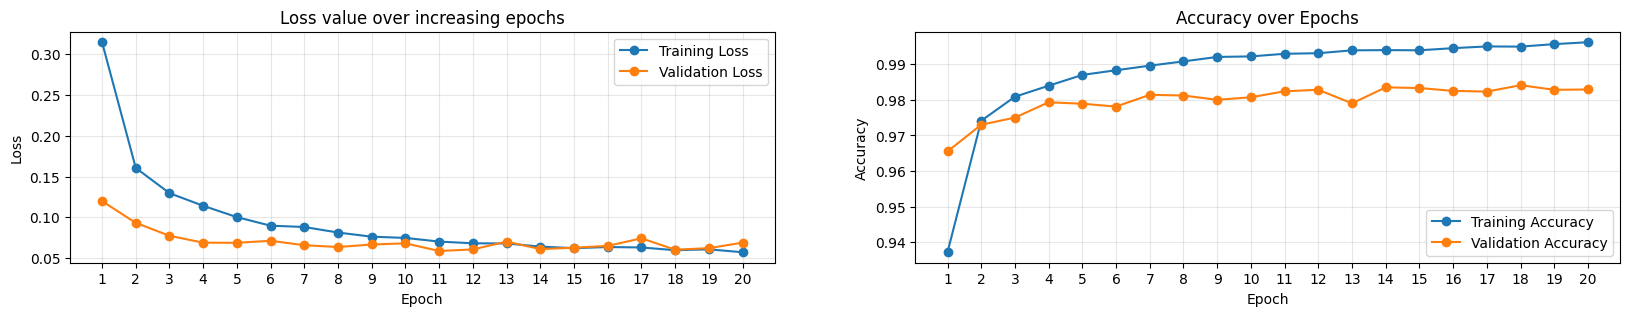

In [11]:
epochs = np.arange(training_epoch) + 1
plt.figure(figsize=(20, 3))
plt.subplot(121)
plt.title("Loss value over increasing epochs")
plt.plot(epochs, losses, marker='o', label="Training Loss")
plt.plot(epochs, val_losses, marker='o', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(122)
plt.title("Accuracy over Epochs")
plt.plot(epochs, accuracies, marker='o', label="Training Accuracy")
plt.plot(epochs, val_accuracies, marker='o', label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [12]:
torch.save(model.state_dict(),'model.pth')

In [13]:
saved_model = get_model()[0]
saved_model.load_state_dict(torch.load('model.pth'))
saved_model.eval()
summary(saved_model,(1,784))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Dropout-1               [-1, 1, 784]               0
            Linear-2              [-1, 1, 1000]         785,000
              ReLU-3              [-1, 1, 1000]               0
            Linear-4               [-1, 1, 512]         512,512
              ReLU-5               [-1, 1, 512]               0
           Dropout-6               [-1, 1, 512]               0
            Linear-7               [-1, 1, 128]          65,664
              ReLU-8               [-1, 1, 128]               0
            Linear-9                [-1, 1, 10]           1,290
Total params: 1,364,466
Trainable params: 1,364,466
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 5.21
Estimated Total Size (MB): 5.24
---------------------------------------

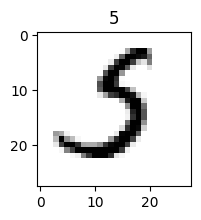

In [64]:
img , label = test[np.random.randint(0,len(test))]
predictOne(model,img)